In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
sns.set(color_codes=True)
sns.set_context('paper')
import plotly.express as px
%matplotlib inline

import cufflinks as cf
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
cf.go_offline()
import plotly.graph_objects as go

data = pd.read_csv("data_new3.csv")
data.head()
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91691 entries, 0 to 91690
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   iso_code                               91691 non-null  object 
 1   continent                              91691 non-null  object 
 2   location                               91691 non-null  object 
 3   date                                   91691 non-null  object 
 4   total_cases                            88454 non-null  float64
 5   new_cases                              88446 non-null  float64
 6   new_cases_smoothed                     87484 non-null  float64
 7   total_deaths                           78575 non-null  float64
 8   new_deaths                             78574 non-null  float64
 9   new_deaths_smoothed                    87484 non-null  float64
 10  total_cases_per_million                88454 non-null  float64
 11  ne

### Adding new features

In [23]:
data.rename(columns={'iso_code':'iso3'}, inplace=True) # necessary for the color coding to work

In [15]:
data["percentage_of_people_vaccinated"] = data["people_vaccinated"] / data["population"] * 100
data["percentage_of_people_fully_vaccinated"] = data["people_fully_vaccinated"] / data["population"] * 100

In [17]:
data = data.drop(data[data.continent.isnull()].index) # remove all statistics for continents

In [21]:
data[data["continent"].isnull()]

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,excess_mortality,percentage_of_people_vaccinated,percentage_of_people_fully_vaccinated


In [24]:
data.to_csv("data_new3.csv", index=False)

# Scatter plot with traces - approach

<AxesSubplot:xlabel='total_vaccinations_per_hundred', ylabel='new_cases_per_million'>

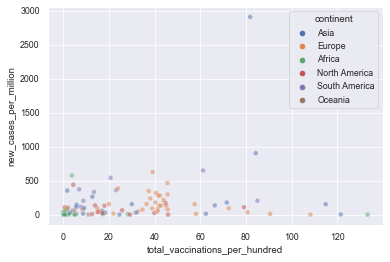

In [3]:
sns.scatterplot(x=vaccinations, y=new_cases, hue=continents, data=selection, alpha=.5)


In [2]:
date = "2021-05-12"
selection = data[data["date"] == date]

vaccinations = selection["total_vaccinations_per_hundred"].dropna()
new_cases = selection["new_cases_per_million"].dropna()
countries = selection["location"]
continents = selection["continent"]

corr = selection.corr()
corr.style.background_gradient(cmap='coolwarm').set_properties(**{'font-size': '0pt'})


C:\Users\f\anaconda3\lib\site-packages\pandas\io\formats\style.py:1264: RuntimeWarning:

All-NaN slice encountered

C:\Users\f\anaconda3\lib\site-packages\pandas\io\formats\style.py:1265: RuntimeWarning:

All-NaN slice encountered



,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,icu_patients,icu_patients_per_million,hosp_patients,hosp_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million,new_tests,total_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,total_vaccinations,people_vaccinated,people_fully_vaccinated,new_vaccinations,new_vaccinations_smoothed,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,new_vaccinations_smoothed_per_million,stringency_index,population,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
total_cases,1.000000,0.664178,0.652959,0.929169,0.758563,0.736686,0.201503,0.076871,0.060346,0.242271,0.208607,0.182023,0.015137,-0.332432,-0.470415,-0.158756,-0.390420,nan,nan,nan,nan,0.896816,0.912023,-0.045208,-0.022243,0.910878,-0.032645,0.144451,-0.061430,0.639805,0.961173,0.916066,0.199135,0.292063,0.120577,0.107680,0.109381,0.000446,0.734441,0.502539,-0.025384,0.160499,0.160707,0.154273,0.135225,-0.117361,-0.124905,0.043676,0.115024,-0.090438,0.080589,0.006051,0.128810,0.169179
new_cases,0.664178,1.000000,0.998466,0.477405,0.931285,0.960915,0.029278,0.087785,0.074198,0.038377,0.139735,0.125190,0.063464,0.959554,0.906338,0.994394,0.940197,nan,nan,nan,nan,0.835131,0.810858,-0.060864,-0.039617,0.853120,-0.038427,0.182210,-0.039288,0.408946,0.715707,0.383853,0.178484,0.239365,-0.040463,-0.042390,-0.072636,-0.063695,0.716459,0.672230,-0.003398,0.029170,0.010766,0.005235,-0.016823,-0.012955,-0.035311,0.041088,-0.038649,-0.097387,0.044346,-0.066026,0.015869,0.013460
new_cases_smoothed,0.652959,0.998466,1.000000,0.455254,0.914051,0.948723,0.021956,0.078450,0.069638,0.025692,0.118223,0.109651,0.057789,0.964618,0.914030,0.996187,0.946362,nan,nan,nan,nan,0.835566,0.811770,-0.060559,-0.039809,0.853667,-0.038443,0.179691,-0.039113,0.409653,0.716624,0.383052,0.178562,0.240947,-0.036633,-0.038589,-0.067348,-0.060133,0.697654,0.675111,-0.002221,0.026505,0.008097,0.003109,-0.016926,-0.008769,-0.027642,0.044029,-0.039453,-0.091281,0.043423,-0.066282,0.011565,0.009926
total_deaths,0.929169,0.477405,0.455254,1.000000,0.670332,0.622880,0.210208,0.067257,0.044241,0.339197,0.282805,0.236836,0.015320,-0.313922,-0.453065,-0.139416,-0.372339,nan,nan,nan,nan,0.716860,0.756981,-0.058398,-0.030607,0.718750,-0.046346,0.151624,-0.077780,0.566229,0.835208,0.854669,0.179068,0.248197,0.115725,0.108327,0.099690,0.000565,0.691662,0.378722,-0.036199,0.183525,0.183537,0.179839,0.130702,-0.154759,-0.149001,0.058561,0.136743,-0.101605,0.157598,0.016196,0.153653,0.194335
new_deaths,0.758563,0.931285,0.914051,0.670332,1.000000,0.993514,0.073706,0.102321,0.079029,0.143937,0.298696,0.251703,0.058900,0.995963,0.971156,0.995992,0.988456,nan,nan,nan,nan,0.825263,0.818041,-0.083635,-0.059625,0.843113,-0.058046,0.222696,-0.055959,0.421826,0.721153,0.444940,0.179492,0.228885,-0.047020,-0.052783,-0.079856,-0.085536,0.666720,0.621883,-0.016607,0.060034,0.033689,0.025896,-0.020104,-0.059679,-0.047025,0.054231,-0.019595,-0.105310,0.063164,-0.048739,0.043917,0.043697
new_deaths_smoothed,0.736686,0.960915,0.948723,0.622880,0.993514,1.000000,0.067603,0.097843,0.079614,0.124140,0.262190,0.234250,0.056152,0.991916,0.961573,0.998638,0.982108,nan,nan,nan,nan,0.826941,0.820373,-0.080955,-0.058648,0.845497,-0.056452,0.213879,-0.055212,0.417776,0.722485,0.422674,0.182761,0.233559,-0.046087,-0.051421,-0.078762,-0.080503,0.659669,0.646066,-0.013897,0.061209,0.034929,0.028118,-0.018005,-0

In [4]:
from matplotlib import rcParams
from ipywidgets import interact, interactive, fixed, interact_manual, IntSlider
from IPython.display import display

rcParams['figure.figsize'] = (10,5)
rcParams['font.size'] = 16

dates = ["2021-01-01", "2021-01-05", "2021-01-10", "2021-01-15", "2021-01-20", "2021-01-25", "2021-01-31", 
        "2021-02-05", "2021-02-10", "2021-02-15", "2021-02-20", "2021-02-25", "2021-02-28", "2021-03-05", "2021-03-10",
        "2021-03-15", "2021-03-20", "2021-03-25", "2021-03-30", "2021-04-05", "2021-04-10", "2021-04-15", "2021-04-20",
        "2021-04-25", "2021-04-30", "2021-05-05", "2021-05-10", "2021-05-15"]


def visualize(steps):

    selection = data[data["date"] == dates[steps]]  
    #print(selection.head())
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=selection.gdp_per_capita, 
            y=selection.median_age, 
            mode="markers", opacity=.5,
            text=selection.location, 
            marker=dict(showscale=True)
            )
        )
    fig.show()

interact(visualize, steps=IntSlider(min=0, max=len(dates)-1, steps=1))

interactive(children=(IntSlider(value=0, description='steps', max=27), Output()), _dom_classes=('widget-intera…

<function __main__.visualize(steps)>

# Multi-Line approach

In [5]:
israel = data[data["location"] == "Israel"]
czechia = data[data["location"] == "Czechia"]
austria = data[data["location"] == "Austria"]
czechia.iloc[0]["population"]


10708982.0

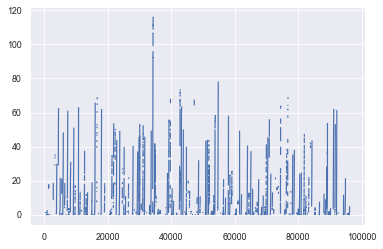

In [5]:
plt.plot(data["percentage_of_people_vaccinated"])

#data["percentage_of_people_vaccinated"]

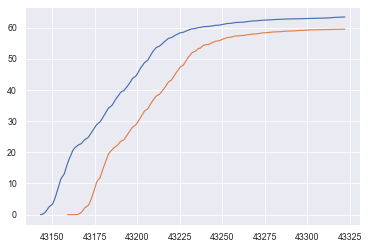

In [9]:
plt.plot(israel["percentage_of_people_vaccinated"])
plt.plot(israel["percentage_of_people_fully_vaccinated"])
plt.show()

In [6]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=israel.date, 
    y=israel.people_vaccinated/israel.iloc[0]["population"], 
    mode='lines',
    name='Israel'))
fig.add_trace(go.Scatter(
    x=czechia.date, 
    y=czechia.people_vaccinated / czechia.iloc[0]["population"], 
    mode='lines',
    name='Czechia'))
fig.add_trace(go.Scatter(
    x=austria.date, 
    y=austria.people_vaccinated / austria.iloc[0]["population"], 
    mode='lines',
    name='Austria'))
fig.show()

"""fig.update_layout(xaxis=dict(
                        showline=True, showgrid=False,
                        showticklabels=True, linecolor='rgb(204, 204, 204)',
                        linewidth=2, ticks='outside', tickfont=dict(
                        family='Arial', size=12)),
                 yaxis=dict(
                         showgrid=False, zeroline=False, showline=False,
                         showticklabels=False), autosize=False, margin=dict(
                                     autoexpand=False, l=100, r=20, t=110, ), 
                         showlegend=False, plot_bgcolor='white')
"""

"fig.update_layout(xaxis=dict(\n                        showline=True, showgrid=False,\n                        showticklabels=True, linecolor='rgb(204, 204, 204)',\n                        linewidth=2, ticks='outside', tickfont=dict(\n                        family='Arial', size=12)),\n                 yaxis=dict(\n                         showgrid=False, zeroline=False, showline=False,\n                         showticklabels=False), autosize=False, margin=dict(\n                                     autoexpand=False, l=100, r=20, t=110, ), \n                         showlegend=False, plot_bgcolor='white')\n"